In [ ]:
# !pip3 install vitaldb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 122.7 MB/s eta 0:00:0000:010:01
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import vitaldb as v

In [ ]:
# from TTransformer import (
#     EmbeddingLayer, 
#     PositionalEncoding, 
#     TransformerBlock, 
#     RegressionHead, 
#     ForecastingModel
# )

# Data overview

In [4]:
track_names = ["SNUADC/ART",        # Arterial pressure wave  | W/500 | mmHg
               "SNUADC/ECG_II",     # ECG lead II wave        | W/500 | mV
               "SNUADC/ECG_V5",     # ECG lead V5 wave        | W/500 | mV
               "BIS/EEG1_WAV",      # EEG wave from channel 1 | W/128 | uV
               "BIS/EEG2_WAV",      # EEG wave from channel 2 | W/128 | uV
               "Solar8000/RR_CO2",  # Respiratory rate based on capnography | N | /min
               "Primus/CO2",        # Capnography wave        | W/62.5 | mmHg
               "BIS/BIS",           # Bispectral index value  |    N   | unitless
               ]

# read 1 patient from the VitalDB server
patient = v.VitalFile(1, track_names)  # should we add max length?
# convert to pandas dataframe
patient = patient.to_pandas(track_names=track_names, interval=5)
# change column names to 'human-readable'
patient.columns = ['arterial_pres', 'ecg1', 'ecg2', 'eeg1', 'eeg2', 'resp_rate', 'capnography', 'bis']

In [5]:
patient

,arterial_pres,ecg1,ecg2,eeg1,eeg2,resp_rate,capnography,bis
0,NaN,NaN,NaN,22.850000,24.700001,NaN,NaN,0.0
1,-7.82223,0.267388,0.267388,23.700001,23.650000,NaN,0.0,0.0
2,-7.82223,3.891360,0.158767,22.750000,24.299999,NaN,0.0,0.0
3,-8.80968,5.145430,0.178517,23.500000,23.799999,NaN,0.0,0.0
4,-7.82223,-0.088097,0.316761,23.250000,24.750000,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...
2304,1.06489,0.395757,0.385883,11.550000,30.000000,NaN,0.0,0.0
2305,-10.78460,0.464879,0.445130,9.400000,30.250000,NaN,0.0,0.0
2306,-1.89748,0.425381,0.415506,12.500000,30.049999,NaN,0.0,0.0
2307,-12.75950,0.405632,0.415506,15.400000,31.750000,NaN,0.0,0.0


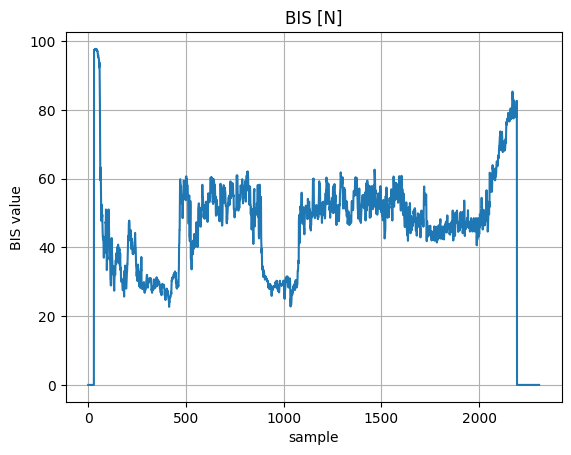

In [6]:
plt.plot(patient.bis)
plt.title('BIS [N]')
plt.xlabel('sample')
plt.ylabel('BIS value')
plt.grid()

Text(0, 0.5, 'Arterial pressure [mmHg]')

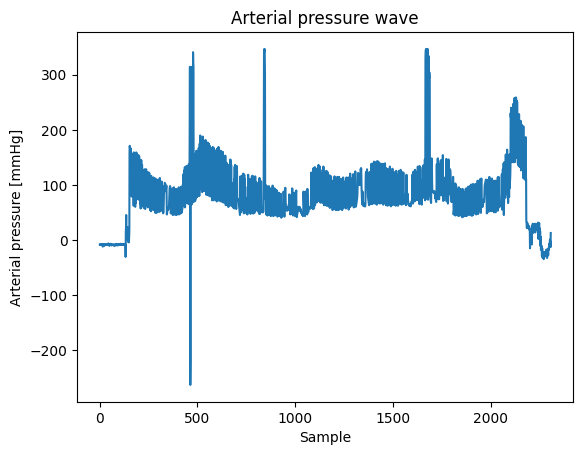

In [7]:
plt.plot(patient.arterial_pres)
plt.title('Arterial pressure wave')
plt.xlabel('Sample')
plt.ylabel('Arterial pressure [mmHg]')

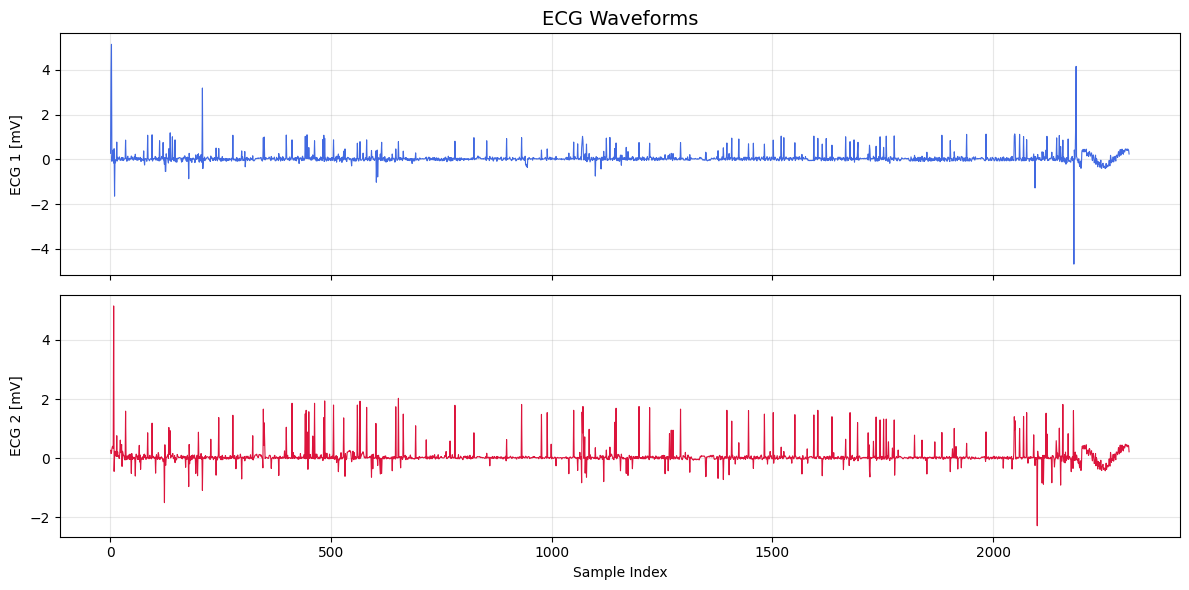

In [8]:
# sharex=True ensures both plots zoom/scroll together
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# 2. Plot the first EEG channel
ax1.plot(patient.ecg1, color='royalblue', linewidth=0.8)
ax1.set_ylabel('ECG 1 [mV]')
ax1.set_title('ECG Waveforms', fontsize=14)
ax1.grid(True, alpha=0.3)

# 3. Plot the second EEG channel
ax2.plot(patient.ecg2, color='crimson', linewidth=0.8)
ax2.set_ylabel('ECG 2 [mV]')
ax2.set_xlabel('Sample Index')
ax2.grid(True, alpha=0.3)

# 4. Remove white space between plots and show
plt.tight_layout()
plt.show()

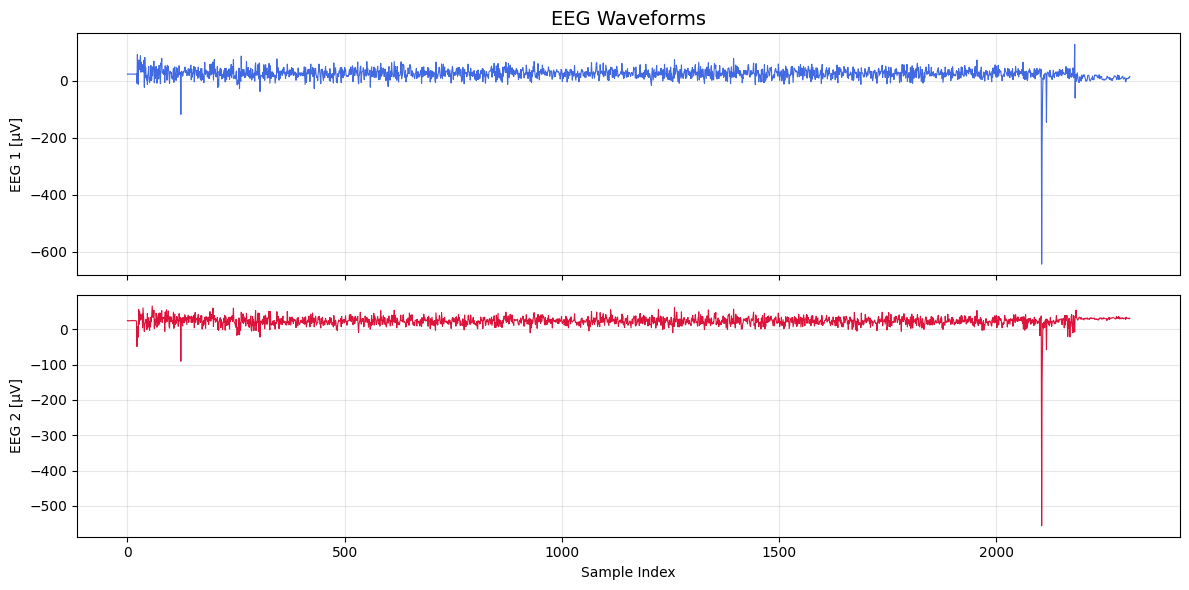

In [9]:
# 1. Create the figure and subplots
# sharex=True ensures both plots zoom/scroll together
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# 2. Plot the first EEG channel
ax1.plot(patient.eeg1, color='royalblue', linewidth=0.8)
ax1.set_ylabel('EEG 1 [μV]')
ax1.set_title('EEG Waveforms', fontsize=14)
ax1.grid(True, alpha=0.3)

# 3. Plot the second EEG channel
ax2.plot(patient.eeg2, color='crimson', linewidth=0.8)
ax2.set_ylabel('EEG 2 [μV]')
ax2.set_xlabel('Sample Index')
ax2.grid(True, alpha=0.3)

# 4. Remove white space between plots and show
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Respiratory rate')

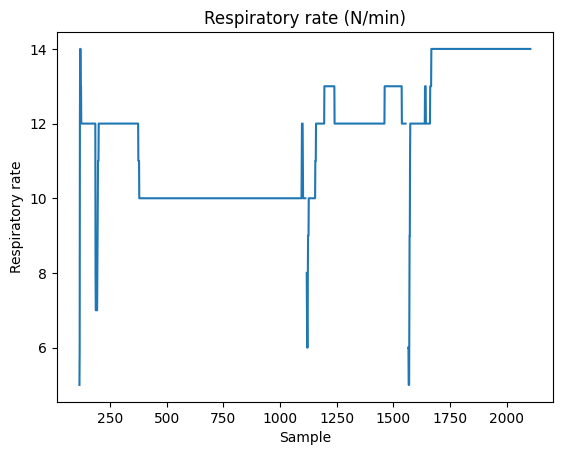

In [10]:
plt.plot(patient.resp_rate) # is this useless ????
plt.title('Respiratory rate (N/min)')
plt.xlabel('Sample')
plt.ylabel('Respiratory rate')

Text(0, 0.5, 'Capnography wave [mmHg]')

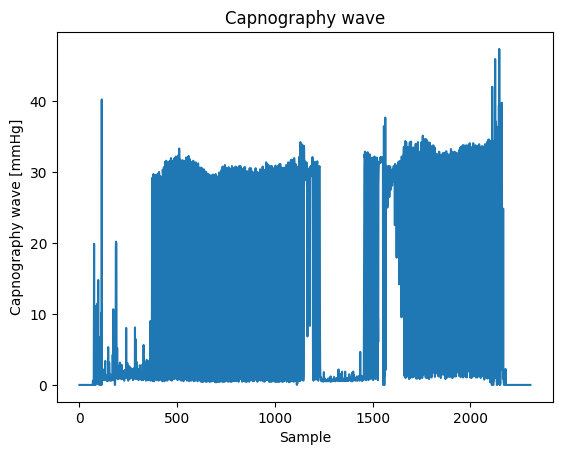

In [11]:
plt.plot(patient.capnography) # is this useless ????
plt.title('Capnography wave')
plt.xlabel('Sample')
plt.ylabel('Capnography wave [mmHg]')

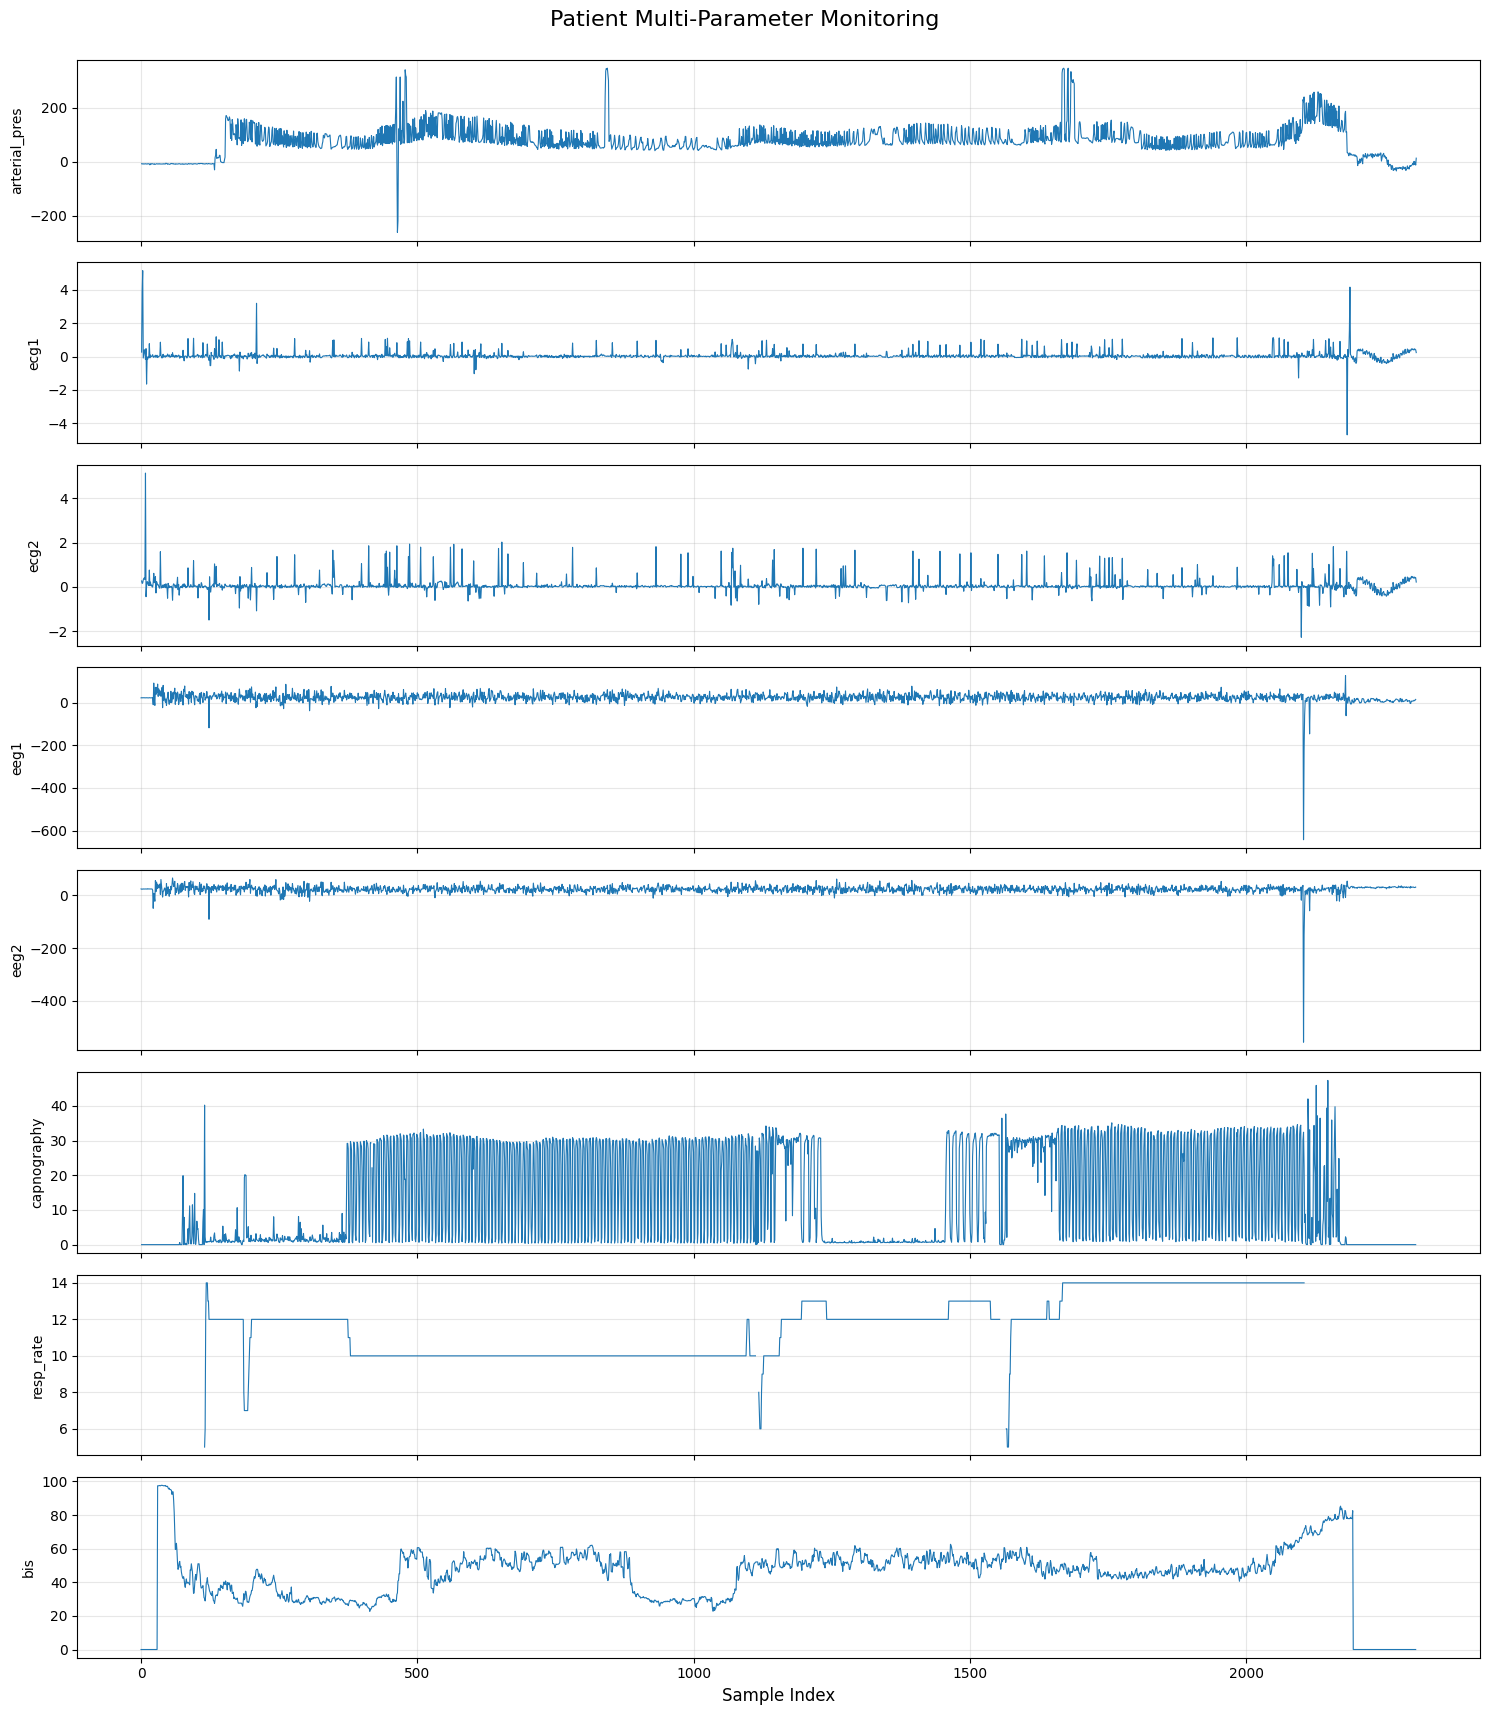

In [12]:
import matplotlib.pyplot as plt

cols_to_plot = [
    'arterial_pres', 
    'ecg1', 
    'ecg2', 
    'eeg1', 
    'eeg2', 
    'capnography', 
    'resp_rate', 
    'bis'
]

fig, axs = plt.subplots(len(cols_to_plot), 1, figsize=(15, 18), sharex=True)

for i, col in enumerate(cols_to_plot):
    data = patient[col].copy()
        
    axs[i].plot(data, linewidth=0.8)
    axs[i].set_ylabel(col, fontsize=10)
    axs[i].grid(True, alpha=0.3)

axs[-1].set_xlabel('Sample Index', fontsize=12)
plt.suptitle('Patient Multi-Parameter Monitoring', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])

plt.show()

# Transformer training 
Preprocess only BIS index - filter values > 0

Original size: 2309 
Size after filtering "bis > 0": 2164
2164


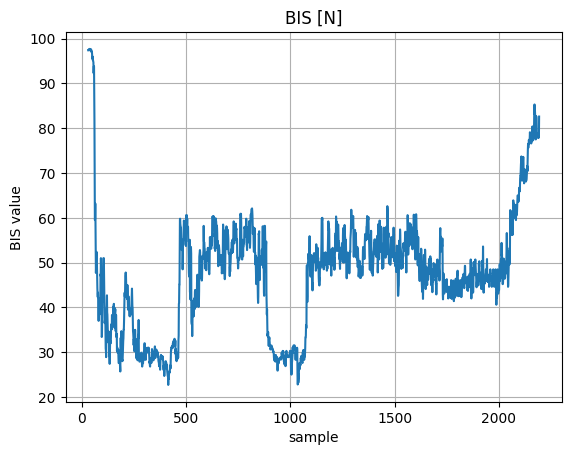

In [13]:
patient_bis_nonzero = patient[patient['bis'] > 0] # also filters out NaNs

print('Original size:', len(patient.bis), '\nSize after filtering "bis > 0":', len(patient_bis_nonzero.bis))
print(len(patient_bis_nonzero))
plt.plot(patient_bis_nonzero.bis)
plt.title('BIS [N]')
plt.xlabel('sample')
plt.ylabel('BIS value')
plt.grid()

In [14]:
NUMBER_OF_PATIENTS = 11
patients = []
for i in range(1, NUMBER_OF_PATIENTS):
    p = v.VitalFile(i, track_names)
    p = p.to_pandas(track_names=track_names, interval=5)
    p.columns = ['arterial_pres', 'ecg1', 'ecg2', 'eeg1', 'eeg2', 'resp_rate', 'capnography', 'bis']
    p = p[p['bis'] > 0]
    patients.append(p)

In [15]:
for i, p in enumerate(patients):
    print(i, len(p))
    # print(p.head(1))

0 2164
1 3012
2 741
3 4033
4 4059
5 681
6 1327
7 1030
8 743
9 4108


### Normalize with Z-score

In [16]:
seq_len = 200
x1 = patients[0].eeg1
x1_mean = np.mean(x1)
x1_std = np.std(x1)
x1_z = [(x1_i - x1_mean)/x1_std for x1_i in x1]

x2 = patients[0].eeg2
x2_mean = np.mean(x2)
x2_std = np.std(x2)
x2_z = [(x2_i - x2_mean)/x2_std for x2_i in x2]

x_z = np.stack([x1_z, x2_z], axis=1) # [[x1[0],x2[0]], [x1[1], x2[1]]...]

In [17]:
print(x1_z[0], x2_z[0])
print(x_z[0])

2.733593 1.1534165
[2.733593  1.1534165]


In [18]:


X = np.array([x_z[i:i+seq_len] for i in range(x_z.shape[0]-seq_len)]).reshape(-1, seq_len, 2)

y = patients[0].bis
y_mean = np.mean(y)
y_std = np.std(y)
y_z = [(y_i - y_mean)/y_std for y_i in y]
Y = np.array([y_z[i+seq_len] for i in range(len(y_z)-seq_len)]).reshape(-1, 1)

print(f"x_z: mean {np.mean(x_z)} std {np.std(x_z)}  y_z: mean {np.mean(y_z)} std{np.std(y_z)}")
print(f"X: {X.shape}, Y: {Y.shape}")



x_z: mean 2.8204786062246967e-08 std 0.9999998211860657  y_z: mean 8.461435641038406e-08 std1.0000008344650269
X: (1964, 200, 2), Y: (1964, 1)


In [19]:
patients[0].head(5)

,arterial_pres,ecg1,ecg2,eeg1,eeg2,resp_rate,capnography,bis
30,-8.80968,-0.058473,0.089645,87.500000,42.849998,NaN,0.0,97.400002
31,-8.80968,-0.028849,0.099520,29.850000,28.549999,NaN,0.0,97.400002
32,-7.82223,0.020523,0.020523,64.949997,38.000000,NaN,0.0,97.400002
33,-8.80968,0.020523,-0.048599,35.099998,29.400000,NaN,0.0,97.599998
34,-7.82223,0.040273,-0.058473,56.650002,43.250000,NaN,0.0,97.500000


### Forecasting model

In [20]:
class EmbeddingLayer(nn.Module):
    def __init__(self, input_size=1, embed_size=8, conv1d_emb=False, kernel_size=3):
        super().__init__()
        self.input_size = input_size
        self.embed_size = embed_size
        self.conv1d_emb = conv1d_emb
        self.kernel_size = kernel_size
        self.padding = kernel_size - 1

        if conv1d_emb:
            self.conv = nn.Conv1d(in_channels=input_size, out_channels=embed_size, kernel_size=kernel_size)
        else:
            self.input_embedding = nn.Linear(input_size, embed_size)
    
    def forward(self, x):
        # shape: (batch, 200, 1)
        if self.conv1d_emb:
            # pad the START of the sequence (dimension 1) with self.padding zeros
            # F.pad(tensor, (left, right, top, bottom), value) — but for 3D tensors
            # the pad tuple goes from last dim backwards: (dim2_left, dim2_right, dim1_left, dim1_right)
            # torch.nn.functional.pad(input, pad, mode='constant', value=None)
            x = F.pad(x, (0, 0, self.padding, 0), "constant", 0)
            # Conv1d expects (batch, channels, length) — transpose dims 1 and 2
            x = x.transpose(2,1)
            # apply convolution
            x = self.conv(x)
            # transpose back to (batch, seq_len, embed_size)
            x = x.transpose(2,1)
        else:
            x = self.input_embedding(x)
        
        return x

In [21]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, 1, d_model)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0)/d_model))

        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)

        pe = pe.transpose(0,1)
        self.register_buffer('pe',pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [22]:
from torch.nn.modules.transformer import TransformerEncoderLayer


class TransformerBlock(nn.Module):
    def __init__(self, embed_size, nhead, dim_feedforward, dropout, seq_len, device):
        super().__init__()
        self.seq_len = seq_len
        self.device = device

        self.encoder_layer = TransformerEncoderLayer(
            d_model=embed_size,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

    def forward(self, x):
        mask = torch.triu(
            torch.full((x.size(1),x.size(1)), float('-inf'), device=self.device),
            diagonal = 1
        )

        x = self.encoder_layer(x, src_mask=mask)
        return x

In [23]:
class RegressionHead(nn.Module):
    def __init__(self, seq_len, embed_size, dim_feedforward, dropout):
        super().__init__()

        flat_size = seq_len * embed_size

        self.linear1 = nn.Linear(flat_size, dim_feedforward)
        self.linear2 = nn.Linear(int(dim_feedforward), int(dim_feedforward/2))
        self.linear3 = nn.Linear(int(dim_feedforward/2), int(dim_feedforward/4))
        self.linear4 = nn.Linear(int(dim_feedforward/4), int(dim_feedforward/16))
        self.linear5 = nn.Linear(int(dim_feedforward/16), int(dim_feedforward/64))
        self.outlayer = nn.Linear(int(dim_feedforward/64), 1)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # shape (batch, seq_len, embed_size)

        # flatten everything except batch dim
        x = x.reshape(x.size(0), x.size(1)*x.size(2))

        # pass through each linear layer with relu + dropout
        x = self.linear1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.linear2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.linear3(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.linear4(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.linear5(x)
        x = self.relu(x)
        x = self.dropout(x)

        return self.outlayer(x)


In [24]:

class ForecastingModel(nn.Module):
    def __init__(self, 
                input_size,
                seq_len, 
                embed_size, 
                nhead, 
                dim_feedforward, 
                dropout, 
                conv1d_emb=True,
                kernel_size=3,
                device='cpu'):
        super().__init__()
        
        self.input_size = input_size
        self.seq_len = seq_len
        self.embed_size = embed_size
        self.nhead = nhead
        self.dim_feedforward = dim_feedforward
        self.dropout = dropout
        self.conv1d_emb = conv1d_emb
        self.kernel_size = kernel_size
        self.device = device

        self.embedding_layer = EmbeddingLayer(
            input_size=input_size,
            embed_size=embed_size,
            conv1d_emb=conv1d_emb,
            kernel_size=kernel_size
        )

        self.pos_encoding = PositionalEncoding(embed_size, dropout)

        self.transformer_block = TransformerBlock(
            embed_size=embed_size, 
            nhead=nhead, 
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            seq_len=seq_len,
            device=device
        )

        self.regression_head = RegressionHead(
            seq_len=seq_len,
            embed_size=embed_size,
            dim_feedforward=dim_feedforward,
            dropout=dropout
        )


    def forward(self, x):
        x = self.embedding_layer(x)
        x = self.pos_encoding(x)
        x = self.transformer_block(x)
        x = self.regression_head(x)
        return x

### Training

In [25]:
from torch.optim.lr_scheduler import ExponentialLR

EPOCHS = 30
BATCH_SIZE = 1
LEARNING_RATE = 2.2e-6
device = 'cuda'

model = ForecastingModel(input_size=2, seq_len=200, embed_size=128, nhead=32,
                         dim_feedforward=1024, dropout=0, device=device)

model.to(device)
model.train()

criterion = torch.nn.HuberLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = ExponentialLR(optimizer, gamma=0.9)

dataset = TensorDataset(torch.tensor(X, dtype=torch.float32).to(device), 
                        torch.tensor(Y, dtype=torch.float32).to(device))
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE)

for epoch in range(EPOCHS):
    for batch_x, batch_y in dataloader:
        optimizer.zero_grad()
        y_hat = model(batch_x)
        loss = criterion(y_hat, batch_y)
        loss.backward()
        optimizer.step()

    scheduler.step()
    print(f"Epoch {epoch+1}/{EPOCHS}: Loss={loss.item():.6f}")


Epoch 1/30: Loss=2.018914
Epoch 2/30: Loss=1.475059
Epoch 3/30: Loss=1.315723
Epoch 4/30: Loss=1.496588
Epoch 5/30: Loss=2.018013
Epoch 6/30: Loss=2.018360
Epoch 7/30: Loss=2.018675
Epoch 8/30: Loss=2.018958
Epoch 9/30: Loss=2.019213
Epoch 10/30: Loss=2.019441
Epoch 11/30: Loss=2.019647
Epoch 12/30: Loss=2.019831
Epoch 13/30: Loss=2.019997
Epoch 14/30: Loss=2.020146
Epoch 15/30: Loss=2.020280
Epoch 16/30: Loss=2.020400
Epoch 17/30: Loss=2.020509
Epoch 18/30: Loss=2.020607
Epoch 19/30: Loss=2.020694
Epoch 20/30: Loss=2.020773
Epoch 21/30: Loss=2.020844
Epoch 22/30: Loss=2.020908
Epoch 23/30: Loss=2.020965
Epoch 24/30: Loss=2.021016
Epoch 25/30: Loss=2.021063
Epoch 26/30: Loss=2.021105
Epoch 27/30: Loss=2.021142
Epoch 28/30: Loss=2.021176
Epoch 29/30: Loss=2.021207
Epoch 30/30: Loss=2.021234
